<a href="https://colab.research.google.com/github/SathyaPrakashD/PyTorch-for-Deep-Learning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — PyTorch Workflow 🔥

> **Notebook Goal:** Learn the complete, end-to-end workflow for building, training, evaluating, saving, and loading a machine learning model using PyTorch.

---

## 📋 What You'll Learn

| Step | Topic |
|------|-------|
| 1 | Data preparation & loading |
| 2 | Building a model |
| 3 | Training the model (loss + optimizer) |
| 4 | Evaluating model performance |
| 5 | Saving & loading a trained model |
| 6 | Putting it all together |

---

## 🔑 Key Concepts
- **Tensors** — the fundamental data structure in PyTorch (similar to NumPy arrays)
- **nn.Module** — the base class for all neural network models in PyTorch
- **Loss Function** — measures how wrong the model's predictions are
- **Optimizer** — adjusts model parameters to reduce the loss
- **Epoch** — one complete pass through the training dataset

> 💡 **Beginner Tip:** Don't worry if not everything makes sense on the first read. The best way to learn is to run each cell, observe the output, and experiment with the values!

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 0: Import Libraries
# ─────────────────────────────────────────────────────────────

import torch                        # Core PyTorch library — tensors, autograd, etc.
from torch import nn                # Neural network building blocks (layers, loss functions)
import matplotlib.pyplot as plt     # For plotting and visualizing data

# ── Verify the PyTorch version installed ──────────────────────
# PyTorch 2.x+ is recommended for this notebook.
torch.__version__

'2.10.0+cpu'

## 1. Data (Preparing and Loading) 📊

In machine learning, **data is everything**. Your data can come in many forms:

| Type | Examples |
|------|---------|
| Tabular | Excel spreadsheet, CSV files |
| Images | JPEG, PNG, medical scans |
| Video | MP4, surveillance footage |
| Audio | MP3, speech recordings |
| Text | Books, tweets, code |
| Biological | DNA sequences, protein structures |

### The Two Core Problems of Machine Learning
1. **Get data** → Convert it into a numerical representation (tensors).
2. **Build a model** → That can learn patterns, features, and relationships in that data.

---

### Our Example: Linear Regression with Known Parameters

To showcase the PyTorch workflow, we'll create **synthetic data** using the linear regression formula:

$$y = weight \times X + bias$$

> 🎯 **Why synthetic data?** Because we know the exact "correct" answer (weight = 0.7, bias = 0.3), we can verify whether our model learned the right values!

In [ ]:
# ─────────────────────────────────────────────────────────────
# Create Synthetic Data Using Linear Regression Formula
# Formula: y = weight * X + bias  (i.e., y = 0.7X + 0.3)
# ─────────────────────────────────────────────────────────────

# ── "Known" parameters — these are what we want our model to LEARN ──
weight = 0.7   # slope  (b in y = a + bX)
bias   = 0.3   # intercept (a in y = a + bX)

# ── Create input data range ───────────────────────────────────
start = 0       # start of the range
end   = 1       # end of the range (exclusive)
step  = 0.02    # interval between values → gives us 50 data points

# torch.arange() creates a 1-D tensor: [0.00, 0.02, 0.04, ..., 0.98]
# .unsqueeze(dim=1) reshapes it from shape [50] → [50, 1]
# (Most PyTorch models expect features in shape [batch_size, features])
X = torch.arange(start, end, step).unsqueeze(dim=1)

# ── Generate labels using the known formula ───────────────────
y = weight * X + bias  # true target values

# Preview the first 10 samples
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Verify we have 50 samples in both X (features) and y (labels)
len(X), len(y)

(50, 50)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Split Data into Training Set and Test Set
# ─────────────────────────────────────────────────────────────
# This is one of the most important steps in Machine Learning!
#
# WHY split? We train on one portion of data and test on unseen
# data to check if the model *generalizes* (not just memorizes).
#
# Common split: 80% training | 20% testing
# ─────────────────────────────────────────────────────────────

train_split = int(0.8 * len(X))   # 80% of 50 = 40 training samples

# Slice the first 80% for training
X_train, y_train = X[:train_split], y[:train_split]

# Slice the remaining 20% for testing (unseen data)
X_test,  y_test  = X[train_split:], y[train_split:]

# Verify the sizes
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualizing the Data 📈

> *"A picture is worth a thousand numbers."*

Before training any model, it's critical to **visualize your data**. This helps you:
- Spot patterns or trends
- Detect outliers or errors
- Understand the expected relationship between features and labels

**Color convention used throughout this notebook:**
- 🔵 **Blue** → Training data
- 🟢 **Green** → Test data
- 🔴 **Red** → Model Predictions

In [ ]:
# ─────────────────────────────────────────────────────────────
# Reusable Visualization Function
# ─────────────────────────────────────────────────────────────
# We define this helper function once and reuse it throughout
# the notebook to compare training data, test data, and
# model predictions on the same plot.
# ─────────────────────────────────────────────────────────────

def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training data, test data, and (optionally) model predictions.

    Args:
        train_data    : Feature values for the training set (X_train)
        train_labels  : Target values for the training set (y_train)
        test_data     : Feature values for the test set (X_test)
        test_labels   : Target values for the test set (y_test)
        predictions   : Model predictions on test data (optional)
    """

    plt.figure(figsize=(10, 7))

    # Plot training data in BLUE
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in GREEN
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # If predictions are provided, plot them in RED
    if predictions is not None:
        # Ideal: red dots should overlap with green dots (perfect predictions)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Display the legend
    plt.legend(prop={"size": 14})
    plt.title("Training Data, Test Data & Predictions")
    plt.xlabel("X (Feature)")
    plt.ylabel("y (Label / Target)")

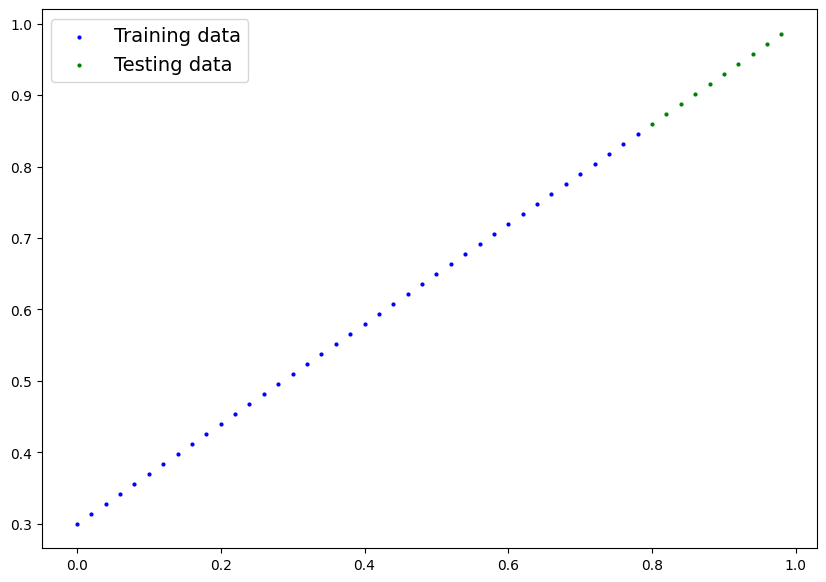

In [ ]:
# Visualize the raw data (no predictions yet)
# Blue = training points | Green = test points
plot_prediction();

## 2. Build a PyTorch Model 🤖

### Our First PyTorch Model

**What does our model do?**
1. Starts with **random values** for weight and bias.
2. Looks at the **training data** and adjusts those random values to better represent the known ideal values (weight = 0.7, bias = 0.3).

**How does it learn?** Through two core algorithms:

| Algorithm | Role |
|-----------|------|
| **Gradient Descent** | Determines the direction and magnitude of parameter updates |
| **Backpropagation** | Computes gradients by chaining derivatives backwards through the model |

> 🧠 **Mental Model:** Think of the model as a student. It starts with random guesses, then gets feedback (loss) on how wrong it is, and keeps adjusting until it gets close to the right answer.

---

### Anatomy of a PyTorch Model

We create a model by subclassing `nn.Module` and defining:
1. `__init__` — initialize learnable parameters
2. `forward()` — define the forward computation (what happens when data passes through)

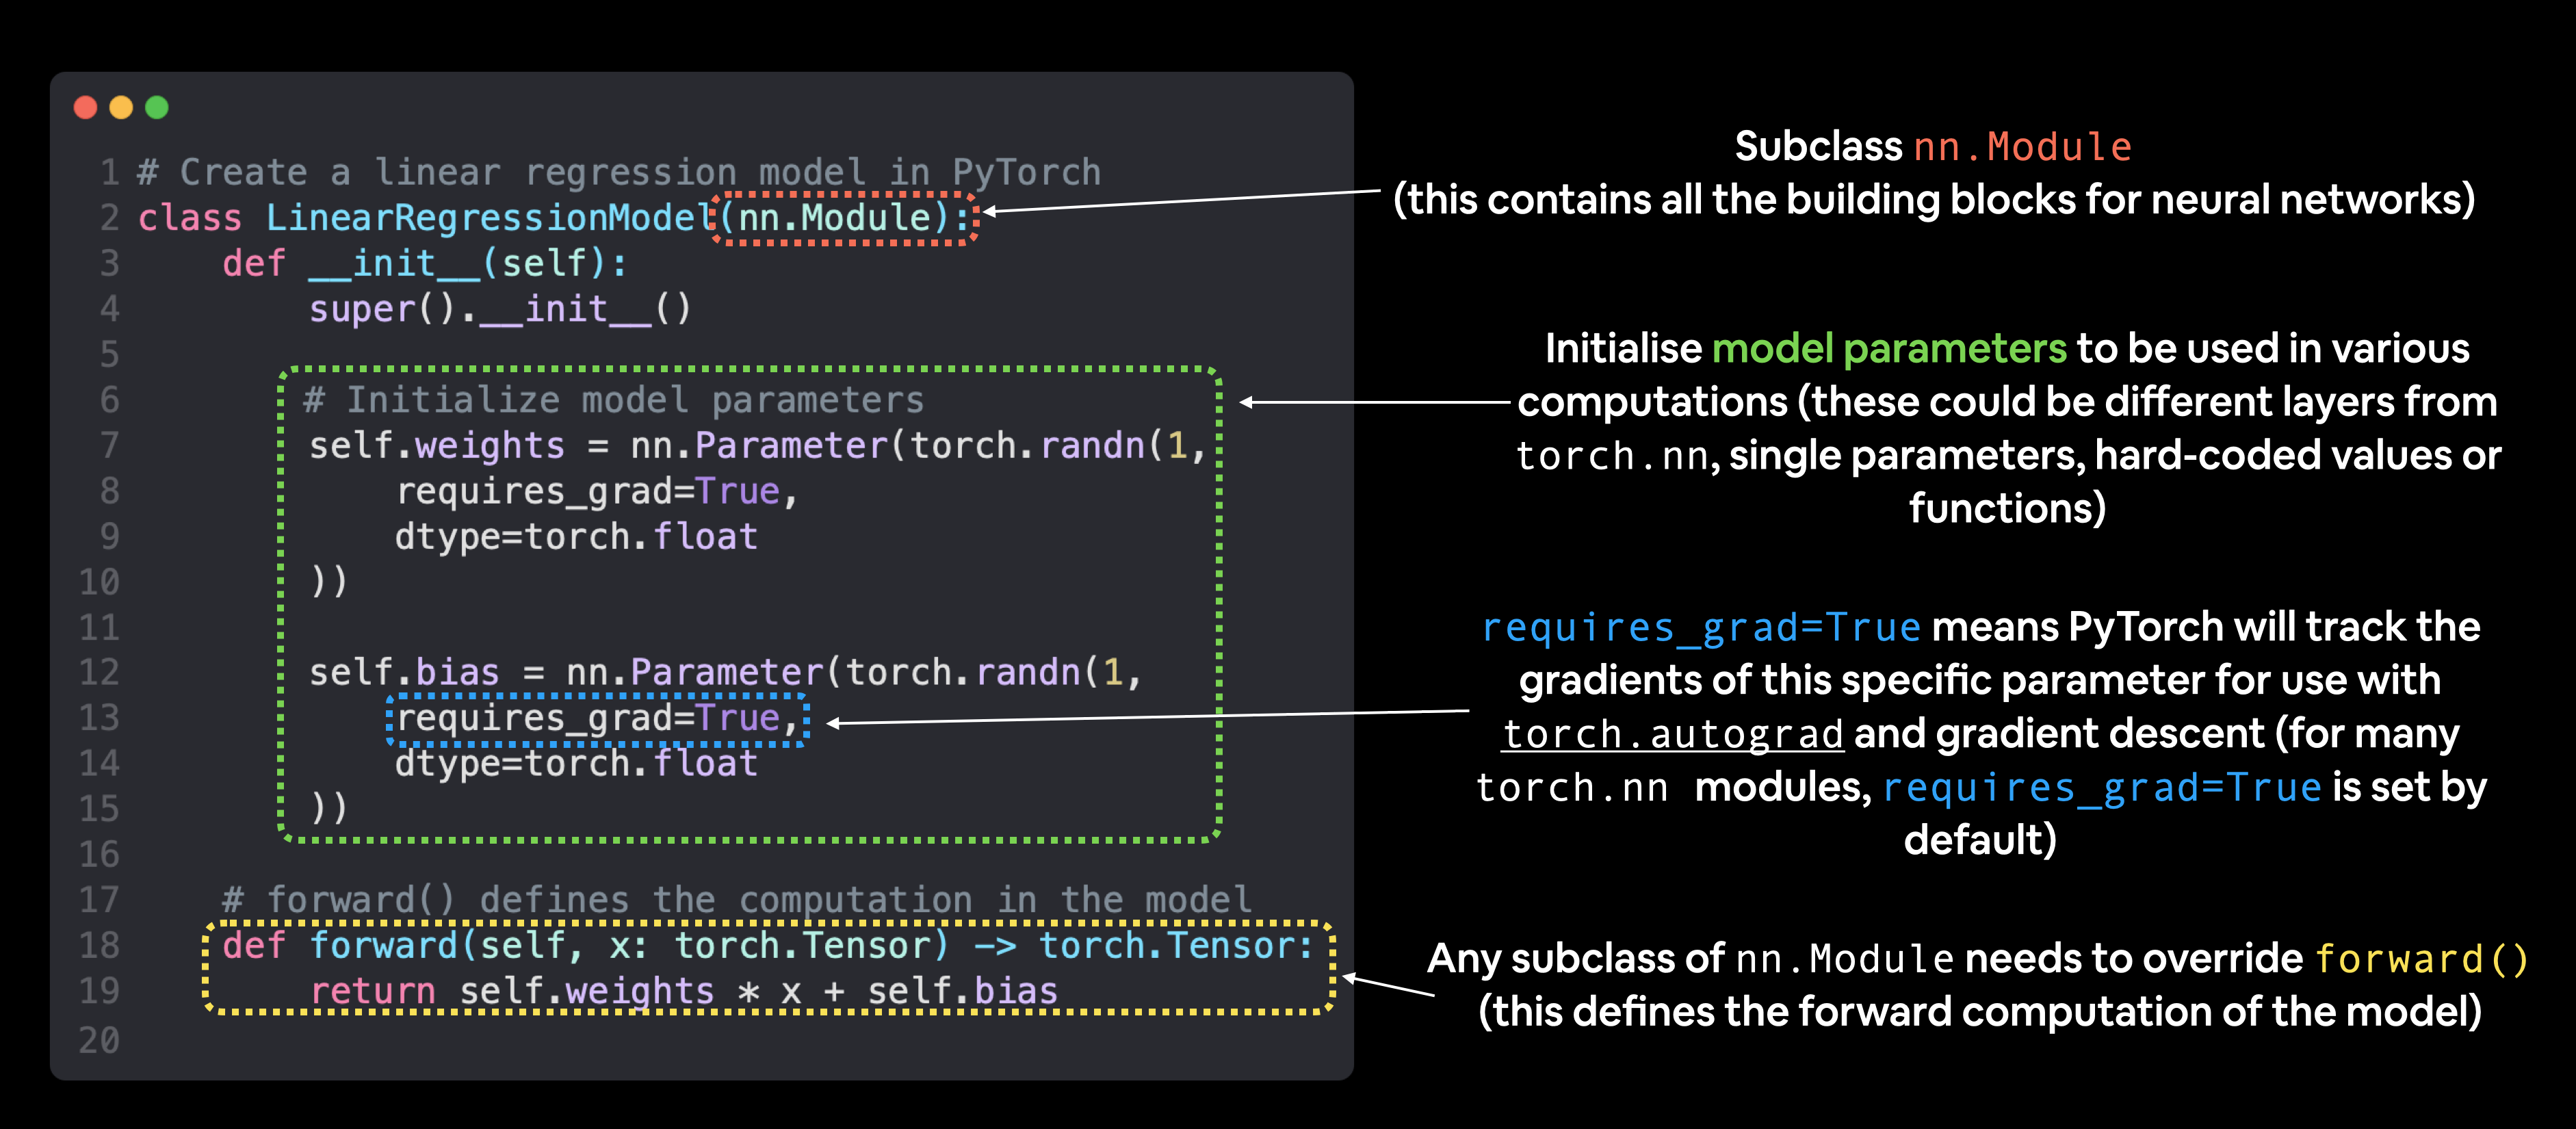

In [ ]:
# ─────────────────────────────────────────────────────────────
# Define a Custom Linear Regression Model (Manual Parameters)
# ─────────────────────────────────────────────────────────────
# This is our first PyTorch model. We manually define weight
# and bias as learnable parameters using nn.Parameter.
# ─────────────────────────────────────────────────────────────

import torch
from torch import nn

class LinearRegressionModel(nn.Module):
    """
    A simple linear regression model: y = weight * x + bias

    This model manually creates learnable parameters (weight & bias)
    using nn.Parameter. PyTorch tracks these and updates them during
    backpropagation.
    """

    def __init__(self):
        super().__init__()   # Always call super().__init__() first!

        # nn.Parameter wraps a tensor and marks it as a learnable parameter.
        # torch.randn(1) initializes it with a random value from N(0,1).
        # requires_grad=True tells PyTorch to compute gradients for this parameter.
        self.weights = nn.Parameter(
            torch.randn(1, requires_grad=True, dtype=torch.float)
        )
        self.bias = nn.Parameter(
            torch.randn(1, requires_grad=True, dtype=torch.float)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass (computation).
        Called automatically when you do: model(input_data)

        Args:
            x (torch.Tensor): Input features
        Returns:
            torch.Tensor: Predictions using y = weights * x + bias
        """
        return self.weights * x + self.bias  # Linear regression formula

## PyTorch Model Building Essentials 🧱

Here's a quick reference for the core PyTorch components used when building models:

| Component | What it Does |
|-----------|-------------|
| `torch.nn` | Contains all building blocks for computational graphs (layers, activations, losses) |
| `torch.nn.Parameter` | Wraps a tensor as a learnable parameter the model will optimize |
| `torch.nn.Module` | **Base class** for all neural network models — your custom model must inherit from this |
| `torch.optim` | Contains optimizers (SGD, Adam, etc.) that update model parameters during training |
| `forward()` | **Required method** in every `nn.Module` subclass — defines how data flows through the model |

> 📌 **Rule of thumb:** Every custom model in PyTorch must:
> 1. Inherit from `nn.Module`
> 2. Define `__init__` to set up parameters/layers
> 3. Override `forward()` to define the computation

### Inspecting the Model's Parameters

Now that we've defined the model, let's see what's inside it.

- `.parameters()` — returns a generator of all learnable parameters (as raw tensors)
- `.state_dict()` — returns an **OrderedDict** of all parameters with their names and values

> 💡 **Tip:** Use `.state_dict()` to view or save named parameters. Use `.parameters()` when passing to an optimizer.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Instantiate the Model
# ─────────────────────────────────────────────────────────────

# Set a manual random seed for reproducibility
# (so we get the same random starting parameters every time)
torch.manual_seed(42)

# Create an instance (object) of our model class
model_0 = LinearRegressionModel()

# List all learnable parameters → returns weight and bias as tensors
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# View the model's named parameters using state_dict()
# Output: OrderedDict with parameter names → current values
#
# Notice: weight ≈ 0.3367, bias ≈ 0.1288
# Target: weight = 0.7,    bias = 0.3   ← (values we want the model to learn)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

> **Observation:** The model's current parameter values are:
> - **weight** ≈ 0.3367 → should be **0.7**
> - **bias**   ≈ 0.1288 → should be **0.3**
>
> These random starting values are far from the ideal values we used to create the data.
> **The goal of training is to get these values as close as possible to 0.7 and 0.3.**

## 3. Making Predictions with `torch.inference_mode()` 🔍

Before we train the model, let's see how poorly it predicts with random parameters.

**How it works:**
When you call `model_0(X_test)`, PyTorch automatically runs the `forward()` method using the current (random) weight and bias values.

### `torch.inference_mode()` vs `torch.no_grad()`

| Context Manager | Purpose |
|----------------|---------|
| `torch.inference_mode()` | **Recommended** — disables gradient tracking AND some other things for maximum speed during inference |
| `torch.no_grad()` | Disables gradient tracking only (slightly less optimized) |

> 💡 **Rule:** Always wrap prediction/evaluation code in `torch.inference_mode()`. This:
> 1. Prevents unnecessary memory usage (no gradient tape needed)
> 2. Speeds up computation
> 3. Avoids accidental parameter updates

In [ ]:
# ─────────────────────────────────────────────────────────────
# Make Predictions Using Untrained (Random) Model Parameters
# ─────────────────────────────────────────────────────────────

# Use torch.inference_mode() to disable gradient tracking during prediction.
# This is the RECOMMENDED way to make predictions (faster and memory-efficient).
with torch.inference_mode():
    y_preds = model_0(X_test)   # Runs forward() with current random parameters

y_preds  # Predicted values (will be far from actual y_test values)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
# Alternative: torch.no_grad() — also disables gradient tracking
# Both produce the same numerical output, but inference_mode() is preferred
# for pure inference because it's slightly faster.
with torch.no_grad():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
# Compare model predictions (y_preds) with actual test labels (y_test)
# Notice how far apart the values are — this is the "loss" we'll minimize.
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

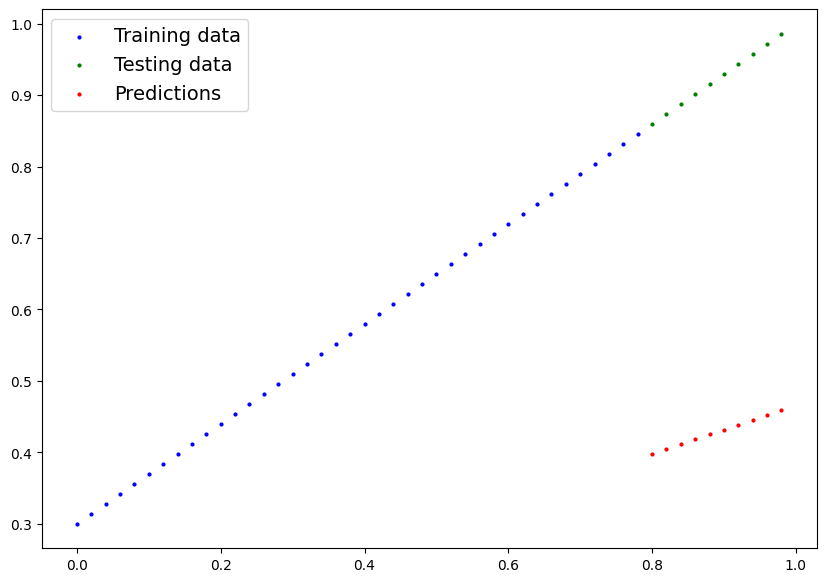

In [ ]:
# Plot the untrained model's predictions vs actual test data
# Observe: Red dots (predictions) are far from Green dots (actual test values).
# After training, the red dots should overlap with the green dots.
plot_prediction(predictions=y_preds)

In [ ]:
# Making predictions WITHOUT torch.inference_mode() or torch.no_grad()
# Notice the output contains 'grad_fn=<AddBackward0>' — this means
# PyTorch is still tracking gradients, which wastes memory/compute.
# Always use inference_mode() for evaluation!
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

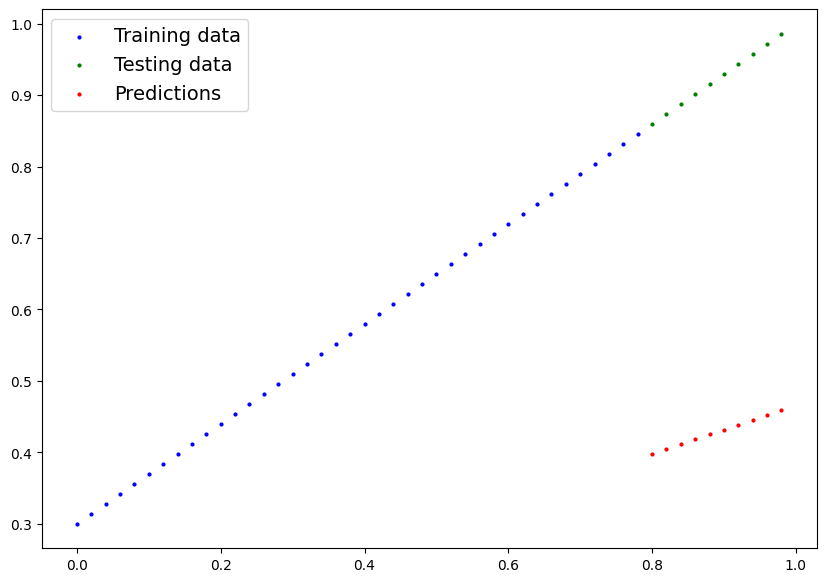

In [ ]:
# If you make predictions WITHOUT inference_mode(), use .detach()
# before passing to matplotlib, because matplotlib can't handle tensors
# that still have gradient information attached.
# .detach() creates a new tensor that shares data but has no gradient.
plot_prediction(predictions=y_preds.detach())

> **Observation:** The red dots (predictions) are clearly **not aligned** with the green dots (test data).
> This is expected — the model starts with **random parameters** (weight ≈ 0.3367, bias ≈ 0.1288) instead of the ideal values (weight = 0.7, bias = 0.3).
>
> **Goal:** Train the model so the red predictions overlap the green test values.

> 🔭 **Future Learning — Transfer Learning:**
> Instead of starting with random parameters, you can use **pre-trained parameters** from another model that was trained on a similar task. This technique is called **Transfer Learning** and often leads to much faster and better training. We'll cover this in a later notebook!

## 4. Train the Model 🏋️

The whole idea of training is to move the model from **unknown (random) parameters** to **known (good) parameters** — in other words, from a poor representation of the data to a better one.

### How Do We Measure "Poorness"? → The Loss Function

A **loss function** (also called cost function or criterion) measures how **wrong** the model's predictions are compared to the true values. **Lower loss = better model.**

| Loss Function | Best Used For | PyTorch Name |
|--------------|---------------|-------------|
| Mean Absolute Error (MAE) | Regression | `nn.L1Loss()` |
| Mean Squared Error (MSE) | Regression | `nn.MSELoss()` |
| Binary Cross-Entropy | Binary classification | `nn.BCELoss()` |
| Cross-Entropy Loss | Multi-class classification | `nn.CrossEntropyLoss()` |

### How Do We Improve? → The Optimizer

An **optimizer** takes the loss and adjusts the model's parameters to reduce it.

| Parameter | What It Controls |
|-----------|-----------------|
| `params` | Which parameters to optimize (usually `model.parameters()`) |
| `lr` (learning rate) | How large each update step is — **the most important hyperparameter** |

> ⚠️ **Learning Rate Tips:**
> - Too **high** → model overshoots and never converges
> - Too **low** → model learns very slowly
> - Common starting values: 0.1, 0.01, 0.001

### What We Need for Training
1. ✅ A **training loop** — iterates over training data and updates parameters
2. ✅ A **testing loop** — evaluates the model on unseen data after each epoch

In [ ]:
# Check the model's current (pre-training) parameters
# weight ≈ 0.3367, bias ≈ 0.1288 (far from target: 0.7, 0.3)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### PyTorch Loss Functions & Optimizers

**Loss Functions in PyTorch (`torch.nn`):**
- PyTorch has ~15+ built-in loss functions
- `nn.L1Loss()` (MAE) and `nn.MSELoss()` — used for **regression** problems
- `nn.BCELoss()`, `nn.CrossEntropyLoss()` — used for **classification** problems

**Key Insight:** Loss and Optimizer work **in tandem** — the loss tells *how wrong* the model is; the optimizer decides *how to fix it*.

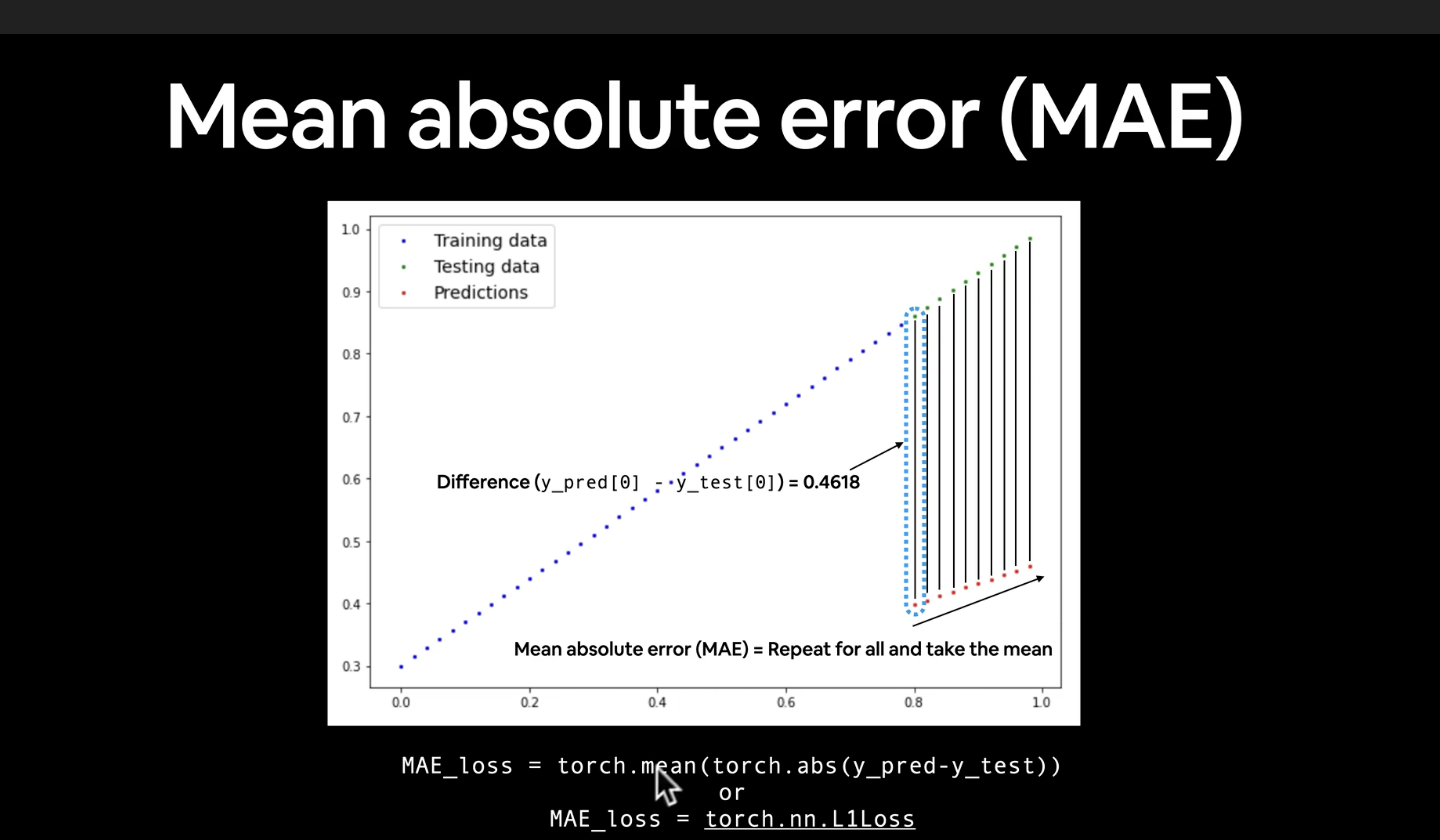

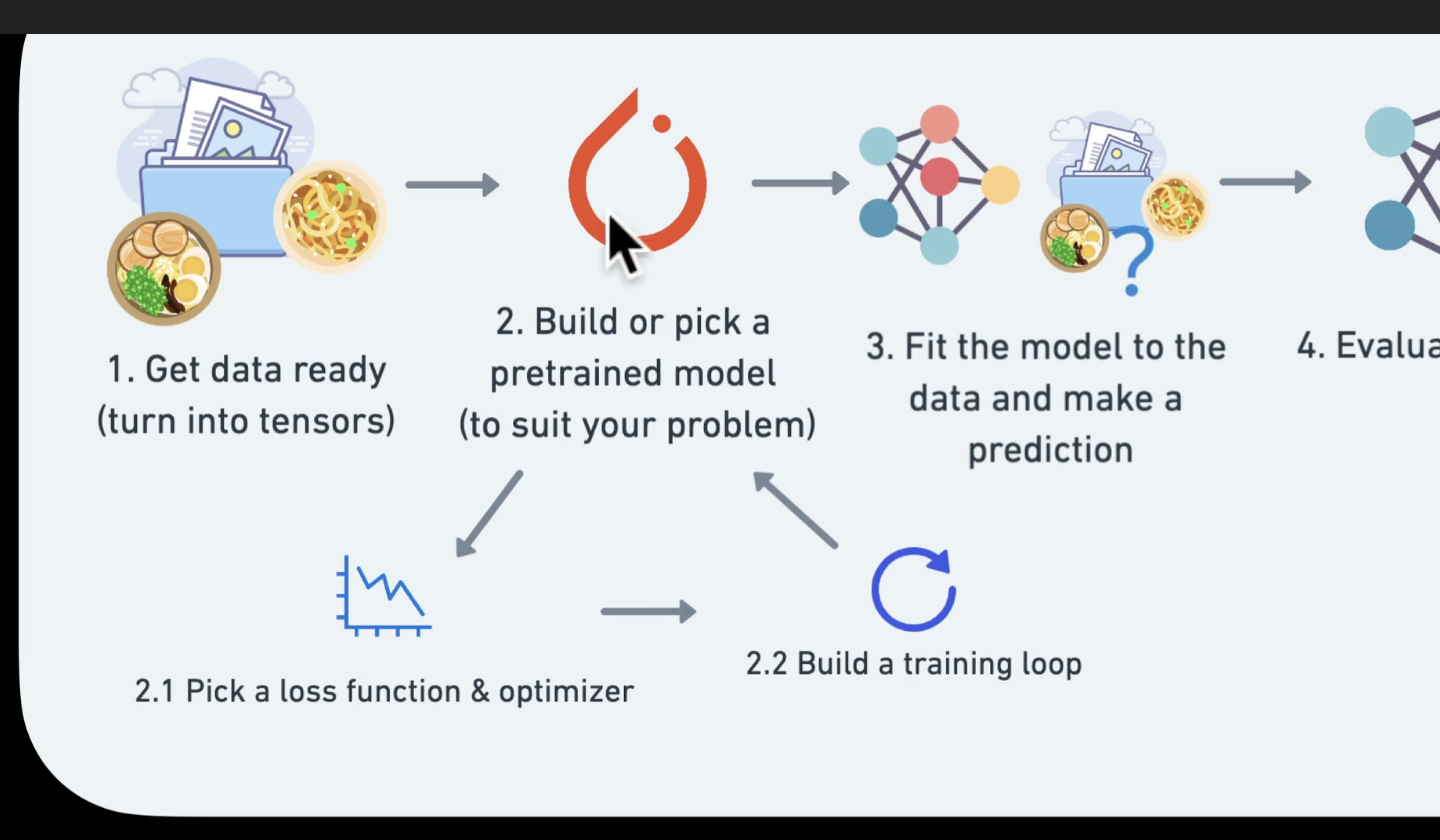

> 🔄 **Loss Function + Optimizer work in tandem:**
> - Loss function → *measures the error*
> - Optimizer → *reduces the error by updating parameters*

### Popular Optimizers in PyTorch (`torch.optim`)

| Optimizer | PyTorch Name | When to Use |
|-----------|-------------|-------------|
| Stochastic Gradient Descent | `torch.optim.SGD` | Good general-purpose starting point |
| Adam | `torch.optim.Adam` | Adaptive learning rate — very popular for deep learning |
| RMSProp | `torch.optim.RMSprop` | Good for RNNs and noisy data |

> **Q: How do I pick the best optimizer?**
> **A:** This is problem-specific. With experience, you'll develop intuition. A common starting recommendation: try **SGD** first for simple problems, **Adam** for complex neural networks. Always experiment with the learning rate!

In [ ]:
# Quick sanity check: view model parameters as a generator
# (We'll pass model_0.parameters() to the optimizer below)

In [ ]:
# model.parameters() returns a generator — PyTorch iterates over
# these internally when the optimizer performs its update step.
model_0.parameters()

<generator object Module.parameters at 0x7e727efc12a0>

In [ ]:
# ─────────────────────────────────────────────────────────────
# Set Up the Loss Function and Optimizer
# ─────────────────────────────────────────────────────────────

# Loss Function: nn.L1Loss = Mean Absolute Error (MAE)
# MAE formula: mean(|y_pred - y_true|) → measures average absolute error
# → Lower is better; 0.0 = perfect predictions
loss_fn = nn.L1Loss()

# Optimizer: Stochastic Gradient Descent (SGD)
# - params: the model parameters to update (weight and bias)
# - lr (learning rate): controls step size during updates
#   → lr=0.001 is small, so training is slow but stable
#   → Try increasing to lr=0.01 and see how it affects convergence speed!
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001)

> **Q: Which loss function and optimizer should I use?**
>
> **A:** It depends on the problem type:
>
> | Problem Type | Recommended Loss | Recommended Optimizer |
> |-------------|-----------------|----------------------|
> | Regression | `nn.L1Loss()` or `nn.MSELoss()` | `SGD` or `Adam` |
> | Binary Classification | `nn.BCELoss()` | `Adam` |
> | Multi-class Classification | `nn.CrossEntropyLoss()` | `Adam` |
>
> With experience, you'll develop an intuition for what works. When in doubt, **experiment and compare results**!

### Building the Training Loop in PyTorch 🔁

A PyTorch training loop follows these **5 steps** in every epoch:

| Step | Action | Code |
|------|--------|------|
| 0 | Set model to training mode | `model.train()` |
| 1 | **Forward pass** — make predictions | `y_pred = model(X_train)` |
| 2 | **Calculate loss** — measure error | `loss = loss_fn(y_pred, y_train)` |
| 3 | **Zero gradients** — clear previous gradients | `optimizer.zero_grad()` |
| 4 | **Backward pass** — compute new gradients | `loss.backward()` |
| 5 | **Optimizer step** — update parameters | `optimizer.step()` |

> ⚠️ **Why `optimizer.zero_grad()`?**
> By default, PyTorch **accumulates** gradients. If you don't zero them out before each backward pass, they add up across batches and produce incorrect updates!

In [ ]:
# ─────────────────────────────────────────────────────────────
# Training Loop (Simple Version — Prints Loss Every Epoch)
# ─────────────────────────────────────────────────────────────
# NOTE: This is a simplified training loop to see the loss decrease.
# In practice, you'd only print every N epochs (see the improved
# version further below with train/test tracking).
# ─────────────────────────────────────────────────────────────

# An epoch = one complete pass through the training data
epochs = 1000

for epoch in range(epochs):

    # ── Step 0: Set model to TRAINING mode ──────────────────
    # .train() enables features like Dropout and BatchNorm
    # that behave differently during training vs. evaluation.
    model_0.train()

    # ── Step 1: FORWARD PASS ────────────────────────────────
    # Pass training data through the model to get predictions
    y_pred = model_0(X_train)

    # ── Step 2: CALCULATE LOSS ──────────────────────────────
    # Compare predictions to actual labels
    loss = loss_fn(y_pred, y_train)
    print(f"Epoch {epoch} | Loss: {loss:.4f}")

    # ── Step 3: ZERO GRADIENTS ──────────────────────────────
    # Clear old gradients before computing new ones
    optimizer.zero_grad()

    # ── Step 4: BACKWARD PASS (Backpropagation) ─────────────
    # Compute gradients of the loss w.r.t. each parameter
    loss.backward()

    # ── Step 5: UPDATE PARAMETERS (Gradient Descent) ────────
    # Adjust weights and bias in the direction that reduces loss
    optimizer.step()

loss : 0.31288138031959534
loss : 0.3117292523384094
loss : 0.3105771541595459
loss : 0.3094250559806824
loss : 0.30827295780181885
loss : 0.3071208596229553
loss : 0.3059687614440918
loss : 0.3048166334629059
loss : 0.30366456508636475
loss : 0.3025124669075012
loss : 0.3013603389263153
loss : 0.30020827054977417
loss : 0.29905614256858826
loss : 0.2979040741920471
loss : 0.2967519462108612
loss : 0.29559987783432007
loss : 0.29444774985313416
loss : 0.293295681476593
loss : 0.2921435832977295
loss : 0.2909914553165436
loss : 0.28983938694000244
loss : 0.28868725895881653
loss : 0.287535160779953
loss : 0.2863830626010895
loss : 0.28523099422454834
loss : 0.2840788662433624
loss : 0.2829267382621765
loss : 0.281774640083313
loss : 0.28062254190444946
loss : 0.2794705033302307
loss : 0.2783183455467224
loss : 0.2771662771701813
loss : 0.27601414918899536
loss : 0.2748620808124542
loss : 0.2737099528312683
loss : 0.2725578844547272
loss : 0.27140578627586365
loss : 0.2702536880970001
lo

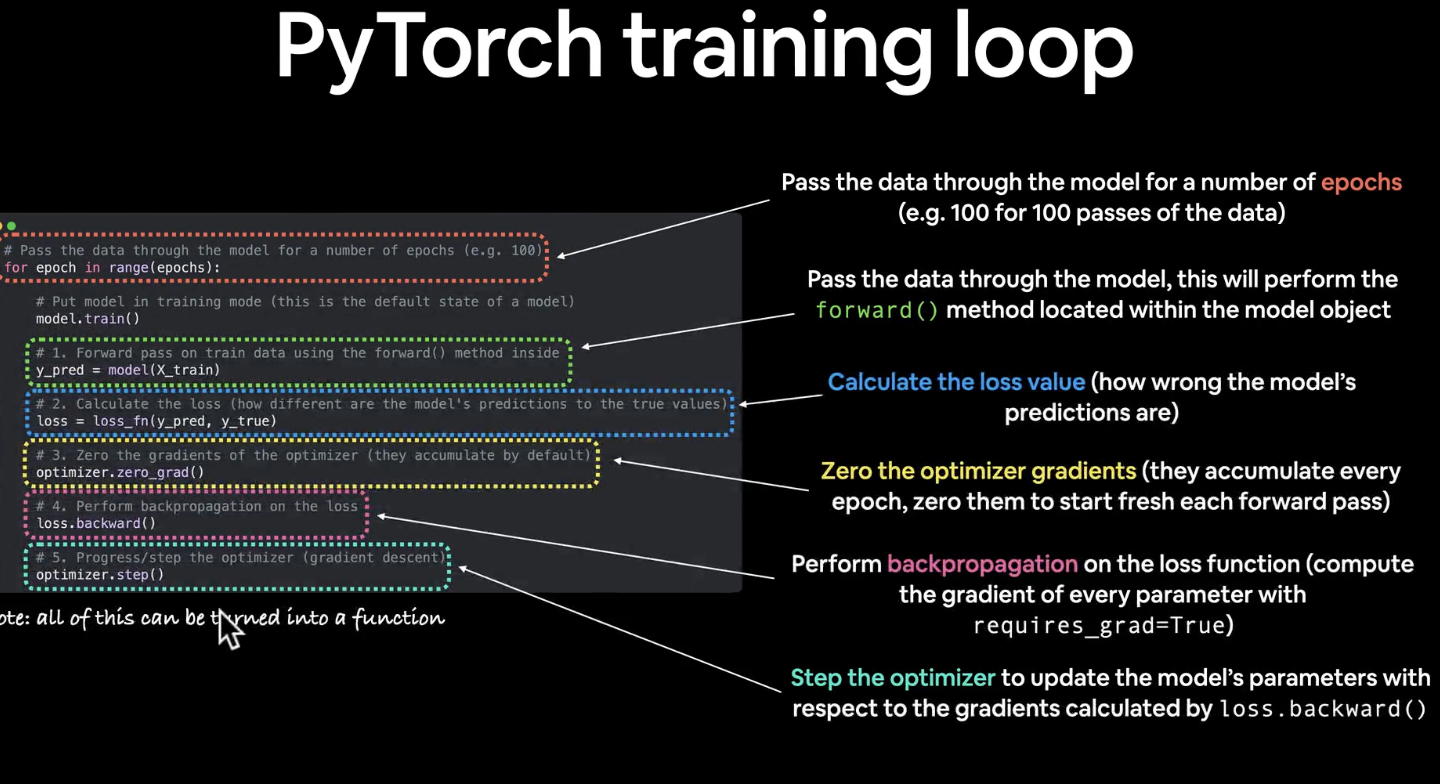

In [ ]:
# Check model parameters AFTER training
# Compare to the initial values: weight ≈ 0.3367, bias ≈ 0.1288
# The values should now be closer to the target: weight = 0.7, bias = 0.3
model_0.state_dict()

OrderedDict([('weights', tensor([0.5788])), ('bias', tensor([0.3509]))])

In [ ]:
# Make new predictions using the TRAINED model parameters
with torch.inference_mode():
    y_preds_new = model_0(X_test)

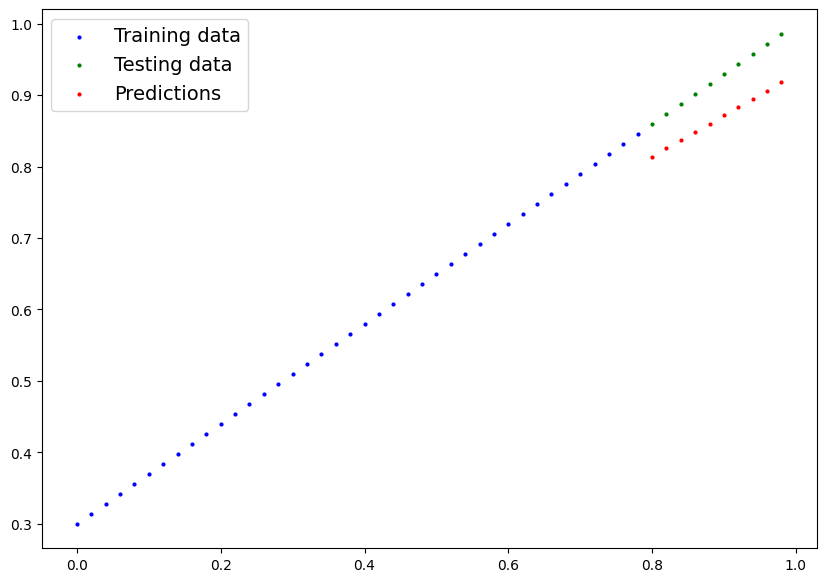

In [ ]:
# Visualize the predictions AFTER training
# The red dots (predictions) should now be much closer to the green dots (test data)
plot_prediction(predictions=y_preds_new)

### ✅ Training Improved the Model!

After 1000 epochs, the loss has dropped significantly and the predictions are much closer to the actual test values.

> 🔑 **Key Takeaway:** The training loop gradually adjusts the model's parameters (weight and bias) in the direction that minimizes the loss. After enough epochs, the parameters converge toward the true values (0.7 and 0.3).

In [ ]:
# ─────────────────────────────────────────────────────────────
# Evaluating the Model on Test Data (Testing Loop)
# ─────────────────────────────────────────────────────────────
# After training, we evaluate on UNSEEN test data to see how
# well the model generalizes beyond the training set.
# ─────────────────────────────────────────────────────────────

# .eval() switches the model to EVALUATION mode
# → Disables Dropout, BatchNorm behaves differently, etc.
model_0.eval()

# torch.inference_mode() disables gradient tracking for efficiency
with torch.inference_mode():

    # Step 1: Forward pass on test data
    y_preds_new = model_0(X_test)

    # Step 2: Calculate test loss (how wrong are predictions on unseen data?)
    test_loss = loss_fn(y_preds_new, y_test)

print(f"Epoch : {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch : 999 | Loss: | 0.02439401112496853 | Test Loss: 0.05694875866174698 


In [ ]:
# ─────────────────────────────────────────────────────────────
# Full Training + Testing Loop (with Loss Tracking)
# ─────────────────────────────────────────────────────────────
# This is the IMPROVED version that:
#   1. Tracks train and test loss at each epoch
#   2. Evaluates on test data inside the same loop
#   3. Only prints every 10 epochs to reduce noise
# ─────────────────────────────────────────────────────────────

epochs = 1000

# Lists to track loss values for later plotting
epoch_count      = []
loss_values      = []   # Training loss per tracked epoch
test_loss_values = []   # Test loss per tracked epoch

for epoch in range(epochs):

    # ── TRAINING PHASE ──────────────────────────────────────
    model_0.train()   # Enable training mode

    # Step 1: Forward pass on training data
    y_pred = model_0(X_train)

    # Step 2: Compute training loss
    train_loss = loss_fn(y_pred, y_train)

    # Step 3: Zero out accumulated gradients
    optimizer.zero_grad()

    # Step 4: Backpropagation — compute gradients
    train_loss.backward()

    # Step 5: Update parameters using computed gradients
    optimizer.step()

    # ── EVALUATION PHASE (no gradients needed) ──────────────
    model_0.eval()
    with torch.inference_mode():
        y_test_pred = model_0(X_test)
        test_loss   = loss_fn(y_test_pred, y_test)

    # ── LOGGING: Record and print every 10 epochs ───────────
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(train_loss.item())       # .item() extracts scalar from tensor
        test_loss_values.append(test_loss.item())
        print(f"Epoch: {epoch:4d} | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

Epoch : 0 | Train Loss: 0.0244 | Test Loss: 0.0569
Current Train Loss for epoch 0: 0.0244
Current Train Loss for epoch 1: 0.0243
Current Train Loss for epoch 2: 0.0243
Current Train Loss for epoch 3: 0.0243
Current Train Loss for epoch 4: 0.0242
Current Train Loss for epoch 5: 0.0242
Current Train Loss for epoch 6: 0.0242
Current Train Loss for epoch 7: 0.0241
Current Train Loss for epoch 8: 0.0241
Current Train Loss for epoch 9: 0.0241
Epoch : 10 | Train Loss: 0.0240 | Test Loss: 0.0561
Current Train Loss for epoch 10: 0.0240
Current Train Loss for epoch 11: 0.0240
Current Train Loss for epoch 12: 0.0239
Current Train Loss for epoch 13: 0.0239
Current Train Loss for epoch 14: 0.0239
Current Train Loss for epoch 15: 0.0238
Current Train Loss for epoch 16: 0.0238
Current Train Loss for epoch 17: 0.0238
Current Train Loss for epoch 18: 0.0237
Current Train Loss for epoch 19: 0.0237
Epoch : 20 | Train Loss: 0.0237 | Test Loss: 0.0553
Current Train Loss for epoch 20: 0.0237
Current Train L

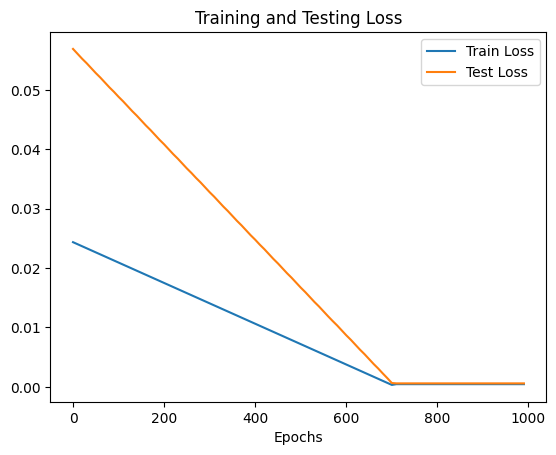

In [ ]:
# ─────────────────────────────────────────────────────────────
# Plot Loss Curves — Training vs. Testing Loss
# ─────────────────────────────────────────────────────────────
# Loss curves are one of the most important diagnostic tools in ML.
#
# What to look for:
#   ✅ Both curves decrease over time → model is learning
#   ⚠️  Train loss decreases but test loss stays high → OVERFITTING
#   ⚠️  Both losses stay high → UNDERFITTING (model too simple or lr too low)
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(epoch_count, loss_values,      label="Train Loss", color="blue")
plt.plot(epoch_count, test_loss_values, label="Test Loss",  color="orange")
plt.title("Training vs. Testing Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MAE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 5. Saving and Loading a PyTorch Model 💾

After all that training, you don't want to redo it every time! PyTorch gives you 3 main methods for saving and loading models:

| Method | Purpose | Use Case |
|--------|---------|----------|
| `torch.save()` | Save any Python object (including model) | Save `state_dict()` to a `.pth` or `.pt` file |
| `torch.load()` | Load a previously saved object | Restore model weights from file |
| `model.load_state_dict()` | Load saved parameters into a model | Must create model instance first, then load weights |

> 📌 **Best Practice:** Save only `model.state_dict()` (the parameters), **not** the entire model object. Saving the full model can break if you rename your class or move to a different Python version.

---

### File Extension Conventions
- `.pth` or `.pt` — both are used; there's no official standard

In [ ]:
# ─────────────────────────────────────────────────────────────
# Save the Trained Model's State Dictionary
# ─────────────────────────────────────────────────────────────

from pathlib import Path

# Step 1: Create a 'models' directory to store saved models
#   parents=True  → create parent directories if they don't exist
#   exist_ok=True → don't raise an error if directory already exists
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Step 2: Define the file path and name for the saved model
MODEL_NAME      = "01_pytorch_workflow_model.pth"   # .pth is a common extension
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME            # → "models/01_pytorch_workflow_model.pth"

# Step 3: Save only the state_dict() — a dict of {parameter_name: tensor_value}
# This is lighter and more portable than saving the entire model object.
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model.pth


In [ ]:
# Verify the saved model file exists and check its size
!ls -lh models/

total 4
-rw-r--r-- 1 root root 2101 May  6 08:58 01_pytorch_workflow_model.pth


## Loading a Saved PyTorch Model 📂

To load a model, we follow this 2-step process:

1. **Create a new instance** of the same model class (with the same architecture)
2. **Load the saved `state_dict()`** into the new instance using `.load_state_dict()`

> ⚠️ **Important:** You must use the **same model class** (same `__init__` and `forward` definition) when loading. PyTorch matches parameters by name, so mismatched architectures will throw an error.

> Since we saved `model.state_dict()` (not the full model object), we need to:
> 1. First **reconstruct** the model architecture by creating a new instance
> 2. Then **inject** the saved parameters using `.load_state_dict()`

In [ ]:
# Review the parameters of the original trained model
# (These are the values we saved to disk)
model_0.state_dict()

OrderedDict([('weights', tensor([0.6994])), ('bias', tensor([0.2998]))])

In [ ]:
# ─────────────────────────────────────────────────────────────
# Load the Saved Model
# ─────────────────────────────────────────────────────────────

# Step 1: Create a new (empty) instance of the same model class
# → At this point, it has RANDOM parameters (not the trained ones)
loaded_model_0 = LinearRegressionModel()

# Step 2: Load the saved state_dict into the new model instance
# torch.load()          → reads the .pth file from disk
# .load_state_dict()    → injects the saved parameters into the model
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Verify: the loaded model should have the SAME parameters as the original
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6994])), ('bias', tensor([0.2998]))])

In [ ]:
# ─────────────────────────────────────────────────────────────
# Make Predictions with the Loaded Model
# ─────────────────────────────────────────────────────────────

# Always set to eval mode before making predictions
loaded_model_0.eval()

with torch.inference_mode():
    loaded_model__preds = loaded_model_0(X_test)

loaded_model__preds  # Should be identical to predictions from original model_0

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

In [ ]:
# Get predictions from the original trained model for comparison
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

In [ ]:
# Verify the loaded model produces IDENTICAL predictions to the original model.
# All values should be True — confirming the save/load cycle worked correctly!
y_preds == loaded_model__preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting It All Together 🎯

Now let's consolidate everything we've learned into a single, clean, end-to-end PyTorch workflow. This time we'll also use:

- **Device-agnostic code** — runs on CPU or GPU automatically
- **`nn.Linear()`** — the cleaner, built-in way to create a linear layer (instead of manually defining weight and bias)

> 🏁 **This section is a complete standalone workflow** — you can use it as a template for your own future projects!

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 0: Import Libraries
# ─────────────────────────────────────────────────────────────

import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np        # Useful for numerical operations (e.g., converting tensors to arrays for plotting)

# Verify PyTorch version
torch.__version__

'2.10.0+cpu'

## Create Device-Agnostic Code 🖥️ / 🎮

One of the most important best practices in PyTorch is writing **device-agnostic code** — code that automatically uses a GPU (CUDA) when available and falls back to CPU when not.

**Why does this matter?**
- GPUs can train neural networks **10x–100x faster** than CPUs
- Writing device-agnostic code means your notebook works on any machine

> 💡 **In Google Colab:** Go to **Runtime → Change runtime type → GPU** to enable GPU acceleration!

In [ ]:
# ─────────────────────────────────────────────────────────────
# Step 1: Setup Device-Agnostic Code
# ─────────────────────────────────────────────────────────────

# torch.cuda.is_available() returns True if a CUDA-capable GPU is found
# We'll move our model and data to this device for faster training
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")
# → "Using device: cuda" if GPU is available (e.g., in Google Colab with GPU runtime)
# → "Using device: cpu"  if no GPU is found

Using device - cpu


## Step 2: Create and Prepare Data 📊

Re-creating the same linear regression dataset (y = 0.7X + 0.3), split into training and test sets.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Create Synthetic Linear Regression Data
# ─────────────────────────────────────────────────────────────

# Known parameters the model should learn
weight = 0.7
bias   = 0.3

# Generate evenly spaced X values from 0 to 1 (50 samples)
start, end, step = 0, 1, 0.02

# X: feature tensor of shape [50, 1]
X = torch.arange(start, end, step).unsqueeze(dim=1)

# y: label tensor using the linear formula y = weight * X + bias
y = weight * X + bias

# Quick preview
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# ─────────────────────────────────────────────────────────────
# Split Data: 80% Training | 20% Testing
# ─────────────────────────────────────────────────────────────

train_split = int(0.8 * len(X))   # 40 training samples

X_train, y_train = X[:train_split], y[:train_split]   # First 80%
X_test,  y_test  = X[train_split:], y[train_split:]   # Last 20%

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

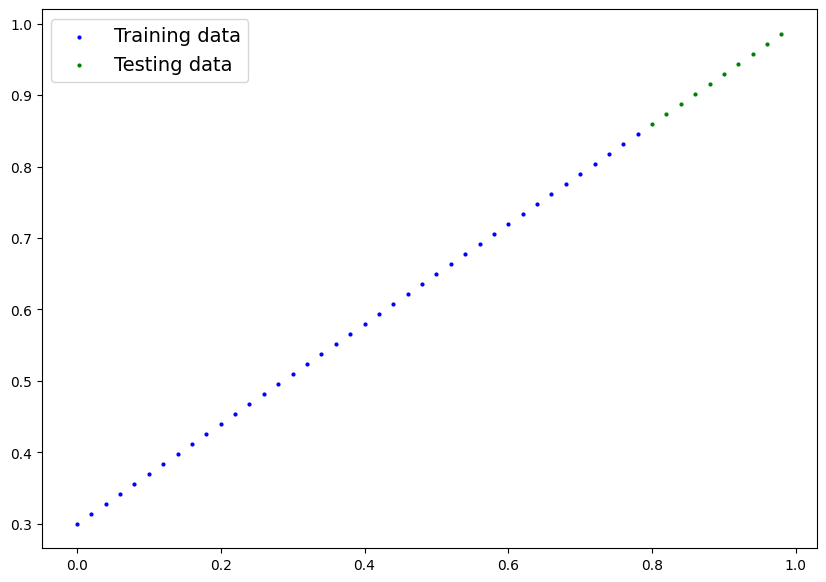

In [ ]:
# Visualize the data split
# Blue = training samples | Green = test samples
plot_prediction(X_train, y_train, X_test, y_test)

## Step 3: Build a PyTorch Linear Model (Version 2) 🏗️

This time, instead of manually defining `weight` and `bias` as `nn.Parameter`, we use **`nn.Linear()`** — PyTorch's built-in linear layer.

### Why `nn.Linear()` is Better

| Approach | How | When to Use |
|----------|-----|------------|
| Manual `nn.Parameter` | Define each parameter by hand | Educational purposes, custom architectures |
| `nn.Linear()` | PyTorch handles parameter creation | **Recommended** for standard linear layers |

`nn.Linear(in_features, out_features)` automatically creates:
- A weight matrix of shape `[out_features, in_features]`
- A bias vector of shape `[out_features]`

In [ ]:
# ─────────────────────────────────────────────────────────────
# Define LinearRegressionModelV2 Using nn.Linear
# ─────────────────────────────────────────────────────────────

from torch import nn


class LinearRegressionModelV2(nn.Module):
    """
    Improved Linear Regression Model using nn.Linear built-in layer.

    nn.Linear(in_features=1, out_features=1) creates:
    - weight: a [1, 1] matrix
    - bias:   a [1] vector
    Both are automatically registered as learnable parameters.
    """

    def __init__(self):
        super().__init__()
        # nn.Linear is equivalent to y = weight * x + bias
        # in_features=1  → input has 1 feature (our X values)
        # out_features=1 → output has 1 value  (our y predictions)
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # The linear_layer handles y = Wx + b internally
        return self.linear_layer(x)


# Set seed for reproducibility, then instantiate model
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

## Step 4: Train the Model 🏋️

Before training, we need to **move the model and data to the target device** (GPU or CPU). This ensures all computations happen on the same hardware.

> ⚠️ **Common Error:** If your model is on GPU but your data is on CPU (or vice versa), PyTorch will raise a `RuntimeError`. Always ensure model and data are on the same device!

In [ ]:
# Check which device the model's parameters are currently on
# next(model_1.parameters()) gets the first parameter tensor
# .device tells us where it lives (cpu or cuda:0)
print(f"Model is on: {next(model_1.parameters()).device}")

cpu


In [ ]:
# ─────────────────────────────────────────────────────────────
# Move Model and Data to the Target Device
# ─────────────────────────────────────────────────────────────

# Move model parameters to device (GPU if available, else CPU)
model_1.to(device)

# Move all data tensors to the same device as the model
# IMPORTANT: Both model and data MUST be on the same device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test,  y_test  = X_test.to(device),  y_test.to(device)

print(f"Model is now on: {next(model_1.parameters()).device}")

Model moved to: cpu


### Training `model_1` — Setup Loss & Optimizer

For training, we need a **loss function** to measure how far off our model's predictions are from the true values, and an **optimizer** to adjust the model's parameters (weights and bias) to minimize this loss. We'll use `nn.L1Loss()` for regression and `torch.optim.SGD()`.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Set Up Loss Function and Optimizer for model_1
# ─────────────────────────────────────────────────────────────

# Loss function: L1 Loss (Mean Absolute Error) — same as before
loss_fn_v2 = nn.L1Loss()

# Optimizer: SGD with a HIGHER learning rate (0.01 instead of 0.001)
# → This will make model_1 converge FASTER than model_0
# → Experiment with different lr values to see the effect!
optimizer_v2 = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

### Building a Training Loop for `model_1`

We'll now implement the training and testing loop, similar to before, but for `model_1` and with the device-agnostic code.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Full Training + Testing Loop for model_1
# ─────────────────────────────────────────────────────────────
# Same structure as before, now with:
#   - model_1 (using nn.Linear)
#   - A higher learning rate (lr=0.01)
#   - Device-agnostic data
# ─────────────────────────────────────────────────────────────

epochs = 1000

epoch_count_v2      = []
loss_values_v2      = []
test_loss_values_v2 = []

for epoch in range(epochs):

    # ── TRAINING ────────────────────────────────────────────
    model_1.train()
    y_pred_v2     = model_1(X_train)
    train_loss_v2 = loss_fn_v2(y_pred_v2, y_train)
    optimizer_v2.zero_grad()
    train_loss_v2.backward()
    optimizer_v2.step()

    # ── EVALUATION ──────────────────────────────────────────
    model_1.eval()
    with torch.inference_mode():
        y_test_pred_v2 = model_1(X_test)
        test_loss_v2   = loss_fn_v2(y_test_pred_v2, y_test)

    # ── LOGGING (every 100 epochs) ──────────────────────────
    if epoch % 100 == 0:
        epoch_count_v2.append(epoch)
        loss_values_v2.append(train_loss_v2.item())
        test_loss_values_v2.append(test_loss_v2.item())
        print(f"Epoch: {epoch:4d} | Train Loss: {train_loss_v2.item():.4f} | Test Loss: {test_loss_v2.item():.4f}")

Epoch : 0 | Train Loss: 0.5552 | Test Loss: 0.5740
Epoch : 100 | Train Loss: 0.0062 | Test Loss: 0.0141
Epoch : 200 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 300 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 400 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 500 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 600 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 700 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 800 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch : 900 | Train Loss: 0.0013 | Test Loss: 0.0138


### Step 5: Evaluate `model_1` — Make and Visualize Predictions 📊

After training, we evaluate the model on the test set to see how well it learned.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Make Predictions with Trained model_1
# ─────────────────────────────────────────────────────────────

model_1.eval()   # Switch to evaluation mode

with torch.inference_mode():
    y_preds_v2 = model_1(X_test)   # Predictions on test set

# Note: If data is on GPU (device='cuda'), move predictions back to CPU for plotting:
# y_preds_v2 = y_preds_v2.cpu()

y_preds_v2

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

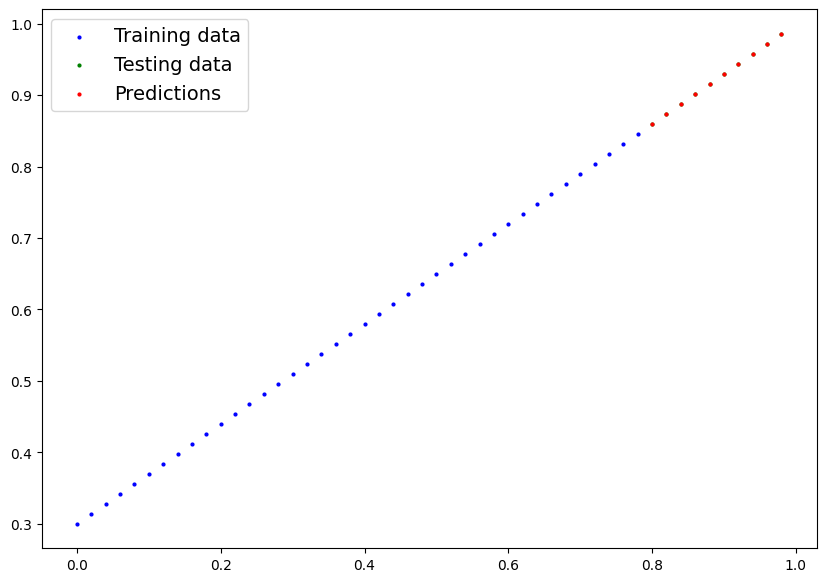

In [ ]:
# Visualize model_1's predictions
# The red dots should closely align with the green test dots
plot_prediction(predictions=y_preds_v2)

### Step 6: Inspect `model_1`'s Learned Parameters 🔍

Let's check how close the learned weight and bias are to the true values (weight = 0.7, bias = 0.3).

In [ ]:
# Check model_1's learned parameters after training
# Expected: linear_layer.weight ≈ 0.7, linear_layer.bias ≈ 0.3
# If both are very close to these values, the model successfully learned the pattern!
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

---

## Summary: The PyTorch Workflow at a Glance

Congratulations on completing the notebook! Here is a recap of everything you learned:

### The 6-Step PyTorch Workflow

| Step | What You Did |
|------|-------------|
| **1. Data** | Created synthetic linear data with known parameters (weight = 0.7, bias = 0.3) |
| **2. Model** | Built two linear regression models using nn.Parameter and nn.Linear |
| **3. Loss + Optimizer** | Used nn.L1Loss() and torch.optim.SGD() to guide learning |
| **4. Train** | Implemented the training loop: forward, loss, zero_grad, backward, step |
| **5. Evaluate** | Checked predictions on unseen test data and plotted loss curves |
| **6. Save and Load** | Saved state_dict() to disk and loaded it back into a fresh model |

---

### Key Takeaways
- **Tensors** are the core data structure — like NumPy arrays but with GPU support and autograd
- **Every model** in PyTorch inherits from nn.Module and must define forward()
- **Training loop** always follows: forward, loss, zero_grad, backward, optimizer step
- **Device-agnostic code** (cuda if available, else cpu) is a best practice for portability
- **Always save state_dict()**, not the whole model, for maximum compatibility

---

### What To Learn Next
- **Classification** — use nn.CrossEntropyLoss() for multi-class problems
- **Deep Neural Networks** — stack multiple nn.Linear layers with non-linear activations (ReLU, etc.)
- **Transfer Learning** — leverage pre-trained model weights instead of starting from scratch
- **Custom Datasets** — use torch.utils.data.Dataset and DataLoader for real-world data pipelines

> **Pro Tip for Revisiting:** Every code cell in this notebook has detailed inline comments explaining *why* each step is done. The markdown cells above each block explain the concepts before the code. Use the Table of Contents (at the top) to quickly jump to any section!

---

## 🎉 Summary — PyTorch Workflow Recap

Congratulations on completing the notebook! Here is what you learned:

### The 6-Step PyTorch Workflow

| Step | What You Did |
|------|-------------|
| **1. Data** | Created synthetic linear data with known parameters (weight=0.7, bias=0.3) |
| **2. Model** | Built two linear regression models using `nn.Parameter` and `nn.Linear` |
| **3. Loss + Optimizer** | Used `nn.L1Loss()` and `torch.optim.SGD()` to guide learning |
| **4. Train** | Implemented the training loop (forward, loss, zero_grad, backward, step) |
| **5. Evaluate** | Checked predictions on unseen test data and plotted loss curves |
| **6. Save and Load** | Saved `state_dict()` to disk and loaded it back into a fresh model |

---

### Key Takeaways
- Tensors are the core data structure — like NumPy arrays with GPU support and autograd
- Every model in PyTorch inherits from `nn.Module` and must define `forward()`
- Training loop always follows: forward, loss, zero_grad, backward, step
- Device-agnostic code using `cuda if available else cpu` is a best practice
- Save `state_dict()`, not the whole model object, for portability

---

### What is Next?
- **Classification** — extend this workflow to multi-class problems
- **Neural Networks** — stack multiple `nn.Linear` layers with activation functions
- **Transfer Learning** — use pre-trained model parameters
- **Custom Datasets** — learn `torch.utils.data.Dataset` and `DataLoader`